# Lecture 5 – Pandas II: grouping, aggregation, and reshaping

QSS 20 · Modern Statistical Computing · Fall 2026

### Agenda

- From a loop to `groupby`, with `pd.concat` on the way.
- How `groupby` works: split, apply, combine.
- Four grouping methods (`agg`, `transform`, `filter`, `apply`) and the
  functions each one accepts.
- Grouping by two columns, and reshaping with `pivot_table`.

## Where we left off

- Last lecture we compared the 80th Congress (1947–49) with the 112th
  (2011–13).
- The gap between the party averages grew from **0.42** to **1.07**, and both
  parties moved.

- Two Congresses show how far the parties moved apart. They do not show
  **when** the move happened.

### Today's question

> **When did the two parties started to polarize?  At what pace?**

- The timing matters because explanations of polarization point to different
  periods.
- Different accounts point to the civil rights laws of the mid-1960s, the
  1980 election, or the 1994 Republican takeover of the House.

### The data, again

- One row is **one member of the House in one Congress**.
- `dwnom1`: negative is liberal, positive is conservative.
- Rows with `district == 0` are **presidents**. We drop them first, as last
  lecture.

In [1]:
import pandas as pd

pd.set_option('display.max_rows', 8)

congress = pd.read_csv('../../data/raw/congress.csv')
house = congress.loc[congress['district'] != 0]
house

,congress,district,state,party,name,dwnom1,dwnom2
1,80,1,ALABAMA,Democrat,BOYKIN F.,-0.026,0.796
2,80,2,ALABAMA,Democrat,GRANT G.,-0.042,0.999
3,80,3,ALABAMA,Democrat,ANDREWS G.,-0.008,1.005
4,80,4,ALABAMA,Democrat,HOBBS S.,-0.082,1.066
...,...,...,...,...,...,...,...
14548,112,6,WISCONS,Republican,PETRI,0.776,-0.003
14549,112,7,WISCONS,Republican,DUFFY,0.781,-0.270
14550,112,8,WISCONS,Republican,RIBBLE,0.886,-0.193
14551,112,1,WYOMING,Republican,LUMMIS,0.932,-0.211


In [2]:
house.shape

(14517, 7)

## Party mean by year

Computing a summary by group is one of the most common tasks in data
analysis.
Start with the tool you already have: a loop.

### A loop over Congresses

- Last lecture ended with this loop over two Congresses.

In [3]:
for c in [80, 112]:
    one = house.loc[house['congress'] == c]
    dem = one.loc[one['party'] == 'Democrat', 'dwnom1'].mean()
    rep = one.loc[one['party'] == 'Republican', 'dwnom1'].mean()
    print(f'Congress {c}:  Democrats {dem:+.3f}   Republicans {rep:+.3f}   gap {rep - dem:.3f}')

Congress 80:  Democrats -0.145   Republicans +0.276   gap 0.421
Congress 112:  Democrats -0.394   Republicans +0.675   gap 1.070


- `range(80, 113)` gives 80, 81, ..., 112. The end is excluded, as always in
  Python.
- Swap it in and the same loop covers all 33 Congresses.

In [4]:
for c in range(80, 113):
    one = house.loc[house['congress'] == c]
    dem = one.loc[one['party'] == 'Democrat', 'dwnom1'].mean()
    rep = one.loc[one['party'] == 'Republican', 'dwnom1'].mean()
    print(f'Congress {c}:  Democrats {dem:+.3f}   Republicans {rep:+.3f}   gap {rep - dem:.3f}')

Congress 80:  Democrats -0.145   Republicans +0.276   gap 0.421
Congress 81:  Democrats -0.194   Republicans +0.264   gap 0.459
Congress 82:  Democrats -0.179   Republicans +0.265   gap 0.444
Congress 83:  Democrats -0.181   Republicans +0.262   gap 0.443
Congress 84:  Democrats -0.209   Republicans +0.262   gap 0.471
Congress 85:  Democrats -0.214   Republicans +0.251   gap 0.465
Congress 86:  Democrats -0.238   Republicans +0.252   gap 0.490
Congress 87:  Democrats -0.222   Republicans +0.251   gap 0.473
Congress 88:  Democrats -0.244   Republicans +0.244   gap 0.488
Congress 89:  Democrats -0.258   Republicans +0.234   gap 0.492
Congress 90:  Democrats -0.254   Republicans +0.226   gap 0.480
Congress 91:  Democrats -0.273   Republicans +0.233   gap 0.506
Congress 92:  Democrats -0.280   Republicans +0.229   gap 0.509
Congress 93:  Democrats -0.299   Republicans +0.228   gap 0.527
Congress 94:  Democrats -0.298   Republicans +0.215   gap 0.513
Congress 95:  Democrats -0.289   Republi

### Keep the results: a function that returns a table

- Step one: turn the loop body into a **function that returns a small
  DataFrame**

In [5]:
def party_means(c):
    one = house.loc[house['congress'] == c]
    return pd.DataFrame({
        'congress': [c],
        'Democrat': [one.loc[one['party'] == 'Democrat', 'dwnom1'].mean()],
        'Republican': [one.loc[one['party'] == 'Republican', 'dwnom1'].mean()],
    })

party_means(80)

,congress,Democrat,Republican
0,80,-0.144907,0.2757


- One row, three columns. Each value sits in a list because a DataFrame column holds a list, even when the list has one entry.
- Step two: call it for every Congress and **collect** the results in a list.

In [6]:
pieces = []
for c in range(80, 113):
    pieces.append(party_means(c))

len(pieces)

33

In [7]:
# A list of 33 one-row DataFrames. The last one:
pieces[-1]

,congress,Democrat,Republican
0,112,-0.394302,0.675325


### Stack the pieces with `pd.concat`

- Step three: stack the 33 tables on top of each other with **`pd.concat`**.

In [8]:
pd.concat(pieces)

,congress,Democrat,Republican
0,80,-0.144907,0.275700
0,81,-0.194489,0.264161
0,82,-0.179298,0.265116
0,83,-0.181070,0.261635
...,...,...,...
0,109,-0.381218,0.594613
0,110,-0.359602,0.626420
0,111,-0.343651,0.657967
0,112,-0.394302,0.675325


- `pd.concat` takes a **list** of DataFrames that share their column names and
  stacks them, top to bottom, in list order.
- 33 rows, one per Congress. Now we have a table.

### ❓ Question

Look at the index on the left of that output. What does this return?

```python
pd.concat(pieces).loc[0]
```

<details><summary>Answer</summary>

**All 33 rows**, not one.

Each small table was built with its own index, and each one's only row was
labeled 0. `pd.concat` keeps the labels it was given, so the stacked table has
the label 0 thirty-three times. `.loc[0]` asks for every row labeled 0.

</details>

### Renumber the rows: `ignore_index=True`

In [9]:
pd.concat(pieces).loc[0].shape

(33, 3)

- The fix: `ignore_index=True` drops the old labels and numbers the stacked
  rows 0, 1, 2, ... from the top.

In [10]:
by_congress = pd.concat(pieces, ignore_index=True)
by_congress

,congress,Democrat,Republican
0,80,-0.144907,0.275700
1,81,-0.194489,0.264161
2,82,-0.179298,0.265116
3,83,-0.181070,0.261635
...,...,...,...
29,109,-0.381218,0.594613
30,110,-0.359602,0.626420
31,111,-0.343651,0.657967
32,112,-0.394302,0.675325


- Now subtraction works on whole columns, as in last lecture.

In [11]:
by_congress['gap'] = by_congress['Republican'] - by_congress['Democrat']
by_congress.sort_values('gap', ascending=False).head(3)

,congress,Democrat,Republican,gap
32,112,-0.394302,0.675325,1.069627
31,111,-0.343651,0.657967,1.001619
30,110,-0.359602,0.626420,0.986021


### The same result in one line: `groupby`

- The loop works. But it is 11 lines for one simple task
- We can do this in one line of code (back to this later)
- Let's start with `groupby` on one variable

In [13]:
# One number for each party.
house.groupby('party')['dwnom1'].mean()

party
Democrat     -0.288030
Other        -0.346842
Republican    0.362816
Name: dwnom1, dtype: float64

- Read it left to right: take `house`, **group** the rows by `party`, take the
  `dwnom1` column in each group, and compute its **mean**.
- The result is a `Series`. Its index holds the group names.

### Split, apply, combine

![Split-apply-combine on six Georgia members of the 112th House. The table is split into a Democratic table and a Republican table, the mean of dwnom1 is computed in each, and the two means are combined into one Series indexed by party](images/split-apply-combine.png)

1. **Split** the rows into one small table per value of `party`.
2. **Apply** a calculation, here `.mean()`, to the chosen column of each small
   table.
3. **Combine** the answers into one result, with one row per group.

- `groupby` does the work of the loop from the start of the lecture.
- The loop's `house.loc[house['congress'] == c]` was the split. The `.mean()`
  was the apply. `pd.concat` was the combine.

## How `groupby` works

```python
house.groupby('party')['dwnom1'].mean()
```

This line has three building blocks.

1. `house.groupby('party')` decides the groups.
2. `['dwnom1']` picks the column to calculate on.
3. `.mean()` is the calculation, done once for each group.

### ❓ Question

What does this line give you, on its own, with nothing after it?

```python
house.groupby('party')
```

<details><summary>Answer</summary>

You do not get a table. You get a `DataFrameGroupBy` object: pandas has sorted
the rows into groups and has not calculated anything yet.

`groupby` does the **split**. The apply and combine only happen when you call a
method such as `.mean()`.

</details>

### Block 1: `groupby` splits the rows

In [14]:
house.groupby('party')

In [15]:
# How many groups did the split make?
house.groupby('party').ngroups

3

- Three groups: Democrat, Other, Republican.
- `.get_group` returns the small table for one group, as the split made it.

In [16]:
house.groupby('party').get_group('Other')

,congress,district,state,party,name,dwnom1,dwnom2
256,80,18,NEW YOR,Other,MARCANTONIO,-0.563,-1.045
263,80,24,NEW YOR,Other,ISACSON,-1.000,-0.011
698,81,18,NEW YOR,Other,MARCANTONIO,-0.657,-1.104
700,81,20,NEW YOR,Other,ROOSEVELT,-0.585,-0.060
...,...,...,...,...,...,...,...
12302,107,1,VERMONT,Other,SANDERS,-0.507,-0.141
12307,107,5,VIRGINI,Other,GOODE,0.620,0.670
12745,108,1,VERMONT,Other,SANDERS,-0.509,-0.034
13184,109,1,VERMONT,Other,SANDERS,-0.510,0.072


- 19 rows: every member outside the two main parties, across all 33
  Congresses.

### Block 2: pick the columns

In [17]:
house.groupby('party')['dwnom1']

- One column name gives a `SeriesGroupBy`. A list of names gives a
  `DataFrameGroupBy`. The rule is the same as for selecting columns from a
  DataFrame.

In [18]:
house.groupby('party')[['dwnom1', 'dwnom2']].mean()

,dwnom1,dwnom2
party,,
Democrat,-0.288030,0.237519
Other,-0.346842,-0.130789
Republican,0.362816,-0.188601


- Pick the columns **before** you calculate. `house.groupby('party').mean()`
  raises a `TypeError`, because pandas cannot average text columns such as
  `state` and `name`.

### Block 3: choose the calculation

- Each comment states a question. The code under it answers that question.

In [19]:
# Typical score in each party. Extreme scores move the median less than the mean.
house.groupby('party')['dwnom1'].median()

party
Democrat     -0.311
Other        -0.503
Republican    0.331
Name: dwnom1, dtype: float64

In [20]:
# How many distinct states has each party represented?
house.groupby('party')['state'].nunique()

party
Democrat      50
Other          7
Republican    50
Name: state, dtype: int64

In [21]:
# How many rows are in each group?
house.groupby('party').size()

party
Democrat      8116
Other           19
Republican    6382
dtype: int64

- `.size()` counts **rows** in each group. It needs no column, because it counts
  rows without reading their values.
- It looks like `value_counts()`. Compare the two.

In [22]:
house['party'].value_counts()

party
Democrat      8116
Republican    6382
Other           19
Name: count, dtype: int64

- Same counts. `value_counts()` sorts by the count, largest first.
  `groupby(...).size()` keeps the groups in label order.

### ❓ Question

What does this return, and about how large are its numbers?

```python
house.groupby('congress').size()
```

The House has 435 seats.

<details><summary>Answer</summary>

One number per Congress: the number of rows for that Congress. They run from
**435 to 446**, not exactly 435.

A member who dies or resigns is replaced, and both people served in that
Congress, so both get a row. This is the row unit again: one row is one
**member** in one Congress, not one **seat**.

</details>

### Rows per Congress

In [23]:
house.groupby('congress').size()

congress
80     445
81     438
82     443
83     435
      ... 
109    438
110    446
111    444
112    442
Length: 33, dtype: int64

In [24]:
house.groupby('congress').size().max()

446

### ❓ Question

What is this calculating?

```python
(house['party'] == 'Democrat').mean()
```

<details><summary>Answer</summary>

  - Last lecture: `True` counts as 1 and `False` as 0, so `.sum()` of a mask
    counts the `True` rows.
  - By the same rule, `.mean()` of a mask is the **share** of rows that are
    `True`.

</details>

- To get that share **for each Congress**, put the mask in the table as a
  column, then group.
- `.assign(name=...)` returns a copy of the table with a new column added.

In [26]:
(
    house
    .assign(is_dem=house['party'] == 'Democrat')
    .groupby('congress')
    ['is_dem']
    .mean()
)

congress
80     0.433708
81     0.598174
82     0.530474
83     0.494253
         ...   
109    0.461187
110    0.540359
111    0.587838
112    0.450226
Name: is_dem, Length: 33, dtype: float64

### Restrict first, then group

- Sometimes the share should be computed only among **some** rows.
- Put the restriction **before** `groupby`. The restriction decides which rows
  enter the groups, and so it decides the **denominator** of every mean.

In [27]:
# Among Democrats only: the mean score in each Congress.
dems = house.loc[house['party'] == 'Democrat']
dems.groupby('congress')['dwnom1'].mean()

congress
80    -0.144907
81    -0.194489
82    -0.179298
83    -0.181070
         ...   
109   -0.381218
110   -0.359602
111   -0.343651
112   -0.394302
Name: dwnom1, Length: 33, dtype: float64

- Every number above is an average over Democrats in one Congress. Republicans
  never entered the calculation.
- Before you report a share or a mean, say in words which rows it is taken
  over.

### ❓ Question

What does `.max()` return on a whole grouped table?

```python
house.groupby('party').max()
```


### Each column is summarized on its own

In [28]:
house.groupby('party').max()

,congress,district,state,name,dwnom1,dwnom2
party,,,,,,
Democrat,112,99,WYOMING,ZIMMERMAN,0.886,1.329
Other,109,24,VIRGINI,SANDERS,0.620,0.995
Republican,112,99,WYOMING,ZWACH J,1.611,0.885


- The Republican row shows a member named `ZWACH J` from Wyoming's district 99
  with a score of 1.611. No such member exists.
- `.max()` took the **largest value of each column separately**: the largest
  Congress number, the largest district, the alphabetically last state, the
  alphabetically last name, the largest score. Those five maxima come from
  different rows.

- Last lecture we found who scored 1.611: Representative Gross of Iowa.
- `groupby` summarizes **each column independently**. The row of maxima does not
  describe any real member.

<div class="alert alert-success">

### Activity 1 · Find the real row

For **each party**, find the full row of the member with the highest `dwnom1`
in the whole file: name, state, Congress, and score.

Two routes work. Try one, then the other if you have time.

1. You met `.idxmax()` last lecture. It returns the **row label** of the largest
   value. Grouped, it returns one label per group.
2. Sort the whole table first, then take the first row of each group with
   `.groupby(...).head(1)`.

Check your answer for Republicans against Gross, 1.611.

</div>

### Route 1: `.idxmax()`, then `.loc`

- `.idxmax()` per party gives three row labels. `.loc` fetches those rows,
  whole.

In [29]:
top_labels = house.groupby('party')['dwnom1'].idxmax()
top_labels

party
Democrat       8035
Other         11866
Republican     5876
Name: dwnom1, dtype: int64

In [30]:
house.loc[top_labels]

,congress,district,state,party,name,dwnom1,dwnom2
8035,98,7,GEORGIA,Democrat,MCDONALD L,0.886,0.401
11866,106,5,VIRGINI,Other,GOODE,0.620,0.670
5876,93,3,IOWA,Republican,GROSS H,1.611,0.461


### Route 2: sort, then take the first row of each group

In [31]:
(
    house
    .sort_values('dwnom1', ascending=False)
    .groupby('party')
    .head(1)
)

,congress,district,state,party,name,dwnom1,dwnom2
5876,93,3,IOWA,Republican,GROSS H,1.611,0.461
8035,98,7,GEORGIA,Democrat,MCDONALD L,0.886,0.401
11866,106,5,VIRGINI,Other,GOODE,0.620,0.670


- `.groupby('party').first()` in place of `.head(1)` gives the same three
  members here, with `party` as the index.
- `.first()` takes the first **non-missing** value of each column. On a table
  with missing values it can mix rows, the same trap as `.max()`.

- Both routes give real members: McDonald of Georgia at 0.886, Goode of
  Virginia at 0.620, Gross of Iowa at 1.611.
- The most conservative Democrat in the file sat in Georgia's delegation, in
  the 98th Congress (1983–85), a Southern Democrat.
- When you need **a whole row** per group, find the row first. Do not
  summarize each column and hope they line up.

## Grouping methods

- Built-in calculations such as `.mean()`, `.size()`, and `.max()` reduce each
  group to one number.

- Four related grouping methods use together with `groupby`:
  - `agg`: several summaries at once, or a summary you write yourself.
  - `transform`: one value for **every row**, computed within its group.
  - `filter`: keep or drop some groups.
  - `apply`: apply operations on each group.

### Grouping method 1: `agg`

- `.agg` computes as many summaries as you ask for, in one table.

In [32]:
# A list of calculation names: one column per calculation.
house.groupby('party')['dwnom1'].agg(['size', 'mean', 'median'])

,size,mean,median
party,,,
Democrat,8116,-0.288030,-0.311
Other,19,-0.346842,-0.503
Republican,6382,0.362816,0.331


In [33]:
# A dictionary: a different calculation for each column.
house.groupby('party').agg({'dwnom1': 'mean', 'state': 'nunique'})

,dwnom1,state
party,,
Democrat,-0.288030,50
Other,-0.346842,7
Republican,0.362816,50


- We call `agg` a **grouping method** because it runs on the result of
  `groupby`. The other three are grouping methods for the same reason.

### `agg` with named outputs

- You choose each output column's name, then say which input column and which calculation produce it.
- Read `members=('name', 'size')` as "make a column called `members` by
  applying `size` to the `name` column".

In [34]:
house.groupby('party').agg(
    members=('name', 'size'),
    mean_score=('dwnom1', 'mean'),
    states=('state', 'nunique'),
)

,members,mean_score,states
party,,,
Democrat,8116,-0.288030,50
Other,19,-0.346842,7
Republican,6382,0.362816,50


### `agg` with your own function

- `.agg` also accepts a function you write.
- How spread out is each party? The range, the largest score minus the
  smallest, gives one answer.

In [35]:
def spread(scores):
    return scores.max() - scores.min()

house.groupby(['congress', 'party'])['dwnom1'].agg(spread).unstack().loc[[80, 112]]

party,Democrat,Other,Republican
congress,,,
80,1.484,0.437,1.461
112,0.731,NaN,1.186


- Democrats spanned 1.48 in the 80th and 0.73 in the 112th. The party became
  far more uniform. The South is one possible source of that change. The
  activity looks at the South from the Republican side.

<div class="alert alert-info">

**Key idea.** A function you give to `agg` takes a **Series** (one column of
one group) and returns **one number**.

</div>

### Grouping method 2: `transform`

- `transform` computes a group summary, then **copies it back onto each row**
  of the group. The result has as many rows as `house`.
- Use it to compare each member with their own party in their own Congress.

In [ ]:
with_party_mean = house.assign(
    party_mean=house.groupby(['congress', 'party'])['dwnom1'].transform('mean')
)
with_party_mean

,congress,party,name,dwnom1,party_mean,distance
1,80,Democrat,BOYKIN F.,-0.026,-0.144907,0.118907
2,80,Democrat,GRANT G.,-0.042,-0.144907,0.102907
3,80,Democrat,ANDREWS G.,-0.008,-0.144907,0.136907
4,80,Democrat,HOBBS S.,-0.082,-0.144907,0.062907
...,...,...,...,...,...,...
14548,112,Republican,PETRI,0.776,0.675325,0.100675
14549,112,Republican,DUFFY,0.781,0.675325,0.105675
14550,112,Republican,RIBBLE,0.886,0.675325,0.210675
14551,112,Republican,LUMMIS,0.932,0.675325,0.256675


In [ ]:
with_party_mean = with_party_mean.assign(
    distance=with_party_mean["dwnom1"] - with_party_mean["party_mean"]
)
with_party_mean[["congress", "party", "name", "dwnom1", "party_mean", "distance"]]

- In the 112th Congress, who sits furthest from their own party's mean?

In [37]:
(
    with_party_mean
    .loc[with_party_mean['congress'] == 112, ['state', 'party', 'name', 'dwnom1', 'distance']]
    .sort_values('distance')
)

,state,party,name,dwnom1,distance
14406,NORTH C,Republican,JONES,0.107,-0.568325
14426,OHIO,Democrat,KUCINICH,-0.779,-0.384698
14537,WASHING,Democrat,MCDERMOT,-0.722,-0.327698
14142,CALIFOR,Democrat,STARK,-0.715,-0.320698
...,...,...,...,...,...
14123,ARIZONA,Republican,FLAKE,1.013,0.337675
14414,NORTH C,Democrat,SHULER,-0.048,0.346302
14547,WISCONS,Republican,SENSENBR,1.200,0.524675
14496,TEXAS,Republican,PAUL,1.293,0.617675


- At one end, Jones of North Carolina, a Republican 0.57 **left** of the
  Republican mean. At the other, Paul of Texas, a Republican 0.62 **right** of
  it.

<div class="alert alert-info">

**Key idea.** `transform` returns **one value for every row**. 

</div>

### Which functions work with `transform`?

- A function works if its result gives **each row** of the group one value.
- Two kinds of calculation names meet that rule. The first kind returns one
  number per group, and `transform` copies it onto every row.

| Name | Each row gets | Common use |
|---|---|---|
| `'mean'`, `'median'` | its group's mean or median | distance from the group's typical value |
| `'sum'` | its group's total | a row's share of its group total |
| `'size'`, `'count'` | its group's number of rows, or of non-missing values | the group size next to each row |
| `'max'`, `'min'` | its group's largest or smallest value | flag the row that holds the maximum |

- The second kind returns a different value for each row.

| Name | Each row gets | Common use |
|---|---|---|
| `'rank'` | its rank within its group | the top members of each group |
| `'cumsum'`, `'cumcount'` | a running total, or a running row number | order within a group |
| `'shift'`, `'diff'` | the previous row's value, or the change from it | change since the previous Congress, per member |

- Pass the names as strings: `'max'`, not Python's `max` or `np.mean`.
  pandas 2.2 accepts those too, but prints a `FutureWarning` that asks for
  the string.

### A value per row: `'rank'`

- Rank each member within their party and Congress. `ascending=False` gives
  rank 1 to the highest, most conservative, score.

In [38]:
ranked = house.assign(
    rank_in_party=house.groupby(['congress', 'party'])['dwnom1']
                       .transform('rank', ascending=False)
)
ranked.loc[(ranked['congress'] == 112) & (ranked['rank_in_party'] <= 2),
           ['party', 'state', 'name', 'dwnom1', 'rank_in_party']]

,party,state,name,dwnom1,rank_in_party
14414,Democrat,NORTH C,SHULER,-0.048,1.0
14436,Democrat,OKLAHOM,BOREN,-0.070,2.0
14496,Republican,TEXAS,PAUL,1.293,1.0
14547,Republican,WISCONS,SENSENBR,1.200,2.0


### Your own function with `transform`

- Write the function with `def`. It receives one group's `dwnom1` column as a
  Series.

In [39]:
def distance_from_mean(scores):
    return scores - scores.mean()

house.groupby(['congress', 'party'])['dwnom1'].transform(distance_from_mean)

1        0.118907
2        0.102907
3        0.136907
4        0.062907
           ...   
14548    0.100675
14549    0.105675
14550    0.210675
14551    0.256675
Name: dwnom1, Length: 14517, dtype: float64

- `scores - scores.mean()` subtracts one number from every value, so the
  function returns a Series of the same length as the group.
- The result is the `distance` column from before, computed in one step.

### ❓ Question

This function returns the two highest scores in a group. What does
`transform` return?

```python
def top_two_scores(scores):
    return scores.sort_values(ascending=False).head(2)

house.groupby(['congress', 'party'])['dwnom1'].transform(top_two_scores)
```

<details><summary>Answer</summary>

A Series with one value for each of the 14,517 rows, and almost all of the
values are `NaN`. pandas does not raise an error.

`transform` puts each returned value back on the row with the same row label.
The function returned two rows per group, so every other row gets `NaN`.

</details>

In [11]:
def top_two_scores(scores):
    return scores.sort_values(ascending=False).head(2)

check = house.groupby(['congress', 'party'])['dwnom1'].transform(top_two_scores)
print('rows:          ', check.shape[0])
print('missing values:', check.isna().sum())

rows:           14517
missing values: 14366


In [16]:
check

1       NaN
2       NaN
3       NaN
4       NaN
         ..
14548   NaN
14549   NaN
14550   NaN
14551   NaN
Name: dwnom1, Length: 14517, dtype: float64

- `transform` lines the results up against the full 14,517-row index by label. Only the 2 top rows in each group get a value; the rest get NaN.
- `transform` is for functions that return either one value per group (like 'mean') or a Series the same length as the group. Anything shorter gets padded with NaN instead of raising an error.

In [20]:
is_top_two = (
    house
    .groupby(["congress", "party"])
    ["dwnom1"]
    .rank(ascending=False) <= 2
)
is_top_two

1        False
2        False
3        False
4        False
         ...  
14548    False
14549    False
14550    False
14551    False
Name: dwnom1, Length: 14517, dtype: bool

In [21]:
house[is_top_two]

,congress,district,state,party,name,dwnom1,dwnom2
193,80,1,MISSISS,Democrat,RANKIN J.,0.234,0.978
256,80,18,NEW YOR,Other,MARCANTONIO,-0.563,-1.045
263,80,24,NEW YOR,Other,ISACSON,-1.000,-0.011
302,80,4,OHIO,Republican,JONES R.,0.722,-0.060
...,...,...,...,...,...,...,...
14414,112,11,NORTH C,Democrat,SHULER,-0.048,0.649
14436,112,2,OKLAHOM,Democrat,BOREN,-0.070,0.988
14496,112,14,TEXAS,Republican,PAUL,1.293,-0.549
14547,112,5,WISCONS,Republican,SENSENBR,1.200,-0.438


### Grouping method 3: `filter`

- A mask with `.loc` keeps or drops **rows**: one decision per row.
- `filter` keeps or drops **whole groups**: one decision per group.

- Example: drop the Congress-party groups with fewer than 10 rows. A mean over
  a few members says little about a party.
- The test is a function that receives one group's table and returns `True`
  or `False`. A test this short can be written inside the call with `lambda`.

In [41]:
kept = (
    house
    .groupby(['congress', 'party'])
    .filter(lambda group: group.shape[0] >= 10)
)
print('rows before:', house.shape[0])
print('rows after: ', kept.shape[0])
print('parties left:', kept['party'].unique())

rows before: 14517
rows after:  14498
parties left: ['Democrat' 'Republican']


- The 19 `Other` rows are gone, because no Congress had 10 of them.
- The result keeps the original rows and row labels. The grouping columns stay
  ordinary columns; they do not become the index.

- Read `lambda group: group.shape[0] >= 10` as "a function that takes `group`
  and returns `group.shape[0] >= 10`".
- The name before the colon is the input. The expression after the colon is
  the return value. A `lambda` has no name and no `return` keyword, and it
  holds one expression only.

<div class="alert alert-info">

**Key idea.** A function you give to `filter` takes a **DataFrame** (one group)
and returns **`True` or `False`**. The groups that get `True` keep all their
rows.

</div>

### The same test as a `def` function

- `spread` and `distance_from_mean` were written with `def`. Any `lambda` can
  be written that way too.

In [42]:
def big_enough(group):
    return group.shape[0] >= 10

kept = house.groupby(['congress', 'party']).filter(big_enough)
kept.shape

(14498, 7)

- The result has the same 14,498 rows as the `lambda` version.

- Pass the function by name, without parentheses: `.filter(big_enough)`.
  pandas then calls it once for each group.

- Use `lambda` for a short function you need once. Use `def` when the
  function needs several lines, or a name you will reuse.
- You will see `lambda` often in documentation and in code base

### Common tests for `filter`

- Any function works if it takes one group's table and returns `True` or
  `False`. Most tests take one of these forms.

| Keep a group when | The function returns |
|---|---|
| it has enough rows | `group.shape[0] >= 10` |
| a group summary passes a threshold | `group['dwnom1'].mean() > 0` |
| a share passes a threshold | `(group['party'] == 'Republican').mean() > 0.5` |
| at least one row meets a condition | `(group['party'] == 'Other').any()` |
| every row meets a condition | `(group['dwnom1'] > 0).all()` |

- `.any()` returns `True` if at least one value in a True/False column is
  `True`. `.all()` returns `True` only if every value is `True`.

In [43]:
# Which Congresses had at least one member outside the two main parties?
with_other = house.groupby('congress').filter(
    lambda group: (group['party'] == 'Other').any()
)
with_other['congress'].unique()

array([ 80,  81,  82,  83,  86,  93,  97, 102, 103, 104, 105, 106, 107,
       108, 109])

- 15 of the 33 Congresses had such a member. `filter` kept every row of those
  15 Congresses, Democrats and Republicans included, because the test is about
  the whole group.

- ⚠️ The function must return `True` or `False`, not a number.
  `.filter(len)` raises `TypeError: filter function returned a int, but
  expected a scalar bool`. Compare the number with a threshold, as
  `big_enough` does.

### ❓ Question

Which Congresses had a Republican majority?

Use `filter` to keep every row of each Congress in which more than half of the
rows are Republicans. Write the test once as a `lambda` and once as a `def`
function named `republican_majority`. Then list the Congress numbers that
remain.

Hint: the mean of a True/False column is a share.

<details><summary>Answer</summary>

```python
majority = house.groupby('congress').filter(
    lambda group: (group['party'] == 'Republican').mean() > 0.5
)

def republican_majority(group):
    return (group['party'] == 'Republican').mean() > 0.5

majority = house.groupby('congress').filter(republican_majority)
majority['congress'].unique()
```

Nine Congresses: the 80th, the 83rd, the 104th through the 109th, and the
112th.

</details>

### Republican majorities

In [44]:
def republican_majority(group):
    return (group['party'] == 'Republican').mean() > 0.5

majority = house.groupby('congress').filter(republican_majority)
majority['congress'].unique()

array([ 80,  83, 104, 105, 106, 107, 108, 109, 112])

- Nine of 33 Congresses. From the 84th to the 103rd, 1955 to 1995, no House
  had a Republican majority. The 104th was the first House after the 1994
  election.
- The share is taken over **rows**, not seats. A member who resigned and the
  replacement both count. In a close House, check the seat counts before you
  name a majority.

### Grouping method 4: `apply`

- Some calculations fit none of `agg`, `transform`, or `filter`. `apply` hands
  your function **one group's whole table**, and the function may return
  anything.
- Example: the gap between the party means **in each Congress**.

- `agg` cannot compute it. `agg` hands your function one column at a time, and
  the gap needs two columns together: `party` to tell the members apart and
  `dwnom1` to average.

In [45]:
def party_gap(one):
    dem = one.loc[one['party'] == 'Democrat', 'dwnom1'].mean()
    rep = one.loc[one['party'] == 'Republican', 'dwnom1'].mean()
    return rep - dem

house.groupby('congress')[['party', 'dwnom1']].apply(party_gap)

congress
80     0.420607
81     0.458649
82     0.444414
83     0.442704
         ...   
109    0.975831
110    0.986021
111    1.001619
112    1.069627
Length: 33, dtype: float64

### `apply` can return a table

- Who were the two most conservative members of each party in the 112th
  Congress (2011–13)?

In [46]:
def top_two(one):
    return one.sort_values('dwnom1', ascending=False).head(2)

(
    house
    .loc[house['congress'] == 112]
    .groupby('party')[['state', 'name', 'dwnom1']]
    .apply(top_two)
)

state      name  dwnom1
party                                      
Democrat   14414  NORTH C    SHULER  -0.048
           14436  OKLAHOM     BOREN  -0.070
Republican 14496    TEXAS      PAUL   1.293
           14547  WISCONS  SENSENBR   1.200

- The result has a two-level index: `party`, then each member's original row
  label.
- The most conservative Democrat, Shuler of North Carolina, scored -0.048. In
  the 98th Congress, McDonald of Georgia scored 0.886. By 2011 no Democrat in
  the House scored above zero.

- Route 2 of Activity 1 does the same job without `apply`: sort, then
  `.groupby('party').head(2)`. The `rank_in_party` column from the
  `transform` section does it too. Prefer either route. `apply` is the
  slowest grouping method and the hardest to read.

<div class="alert alert-info">

**Key idea.** A function you give to `apply` takes a **DataFrame** (one group)
and returns **anything**: a number, a Series, or a table. pandas combines the
results.

</div>

### Review: `apply` with `lambda`

- The body of `top_two` is one line. As in the `filter` section, a `lambda`
  can replace it inside the call.

In [47]:
(
    house
    .loc[house['congress'] == 112]
    .groupby('party')[['state', 'name', 'dwnom1']]
    .apply(lambda one: one.sort_values('dwnom1', ascending=False).head(2))
)

state      name  dwnom1
party                                      
Democrat   14414  NORTH C    SHULER  -0.048
           14436  OKLAHOM     BOREN  -0.070
Republican 14496    TEXAS      PAUL   1.293
           14547  WISCONS  SENSENBR   1.200

- As before, the name before the colon, `one`, is the input: one group's
  table. The expression after the colon is what the function returns.

- The table is the same as the one `top_two` gave. `party_gap` needs three
  lines, so it stays a `def` function.
- Every grouping method accepts either form:

| With `def` | With `lambda` |
|---|---|
| `.agg(spread)` | `.agg(lambda scores: scores.max() - scores.min())` |
| `.transform(distance_from_mean)` | `.transform(lambda scores: scores - scores.mean())` |
| `.filter(big_enough)` | `.filter(lambda group: group.shape[0] >= 10)` |
| `.apply(top_two)` | `.apply(lambda one: one.sort_values('dwnom1', ascending=False).head(2))` |

### The grouping method cheat sheet

| Method | Your function takes | and returns | The result has |
|---|---|---|---|
| `agg` | a Series: one column of one group | one number | one row per group |
| `transform` | a Series: one column of one group | one number, or a Series of the same length | one value per original row |
| `filter` | a DataFrame: one group | `True` or `False` | the original rows of the kept groups |
| `apply` | a DataFrame: one group | anything | whatever the function returns, combined |

- Try the built-in calculations and `agg` first. Reach for `apply` last.
- All four methods accept a `def` function or a `lambda`. `agg` and
  `transform` also accept calculation names in quotes, such as `'mean'`.

## Grouping by two columns

- Our question needs one mean for each **Congress and party**. Pass a list of
  columns to `groupby`.

In [48]:
house.groupby(['congress', 'party'])['dwnom1'].mean()

congress  party     
80        Democrat     -0.144907
          Other        -0.781500
          Republican    0.275700
81        Democrat     -0.194489
                          ...   
111       Democrat     -0.343651
          Republican    0.657967
112       Democrat     -0.394302
          Republican    0.675325
Name: dwnom1, Length: 81, dtype: float64

- Read it as: for every **combination** of `congress` and `party`, the mean
  `dwnom1`.
- The index now has two levels. pandas prints the Congress number once and
  leaves the space blank until it changes.

- `.reset_index()` turns the index levels back into ordinary columns. The
  result is a regular DataFrame again.

In [23]:
long = house.groupby(['congress', 'party'])['dwnom1'].mean().reset_index()
long

,congress,party,dwnom1
0,80,Democrat,-0.144907
1,80,Other,-0.781500
2,80,Republican,0.275700
3,81,Democrat,-0.194489
...,...,...,...
77,111,Democrat,-0.343651
78,111,Republican,0.657967
79,112,Democrat,-0.394302
80,112,Republican,0.675325


- 81 rows: 33 Congresses times 2 main parties, plus 15 Congress-party
  combinations for `Other`.
- `groupby([...], as_index=False)` gives the same table in one step.
- This shape is called **long**: one row per (congress, party) pair.

## Pivot tables

![A long table with one row per congress and party becomes a wide table with one row per congress and one column per party](images/long-to-wide.png)

- `pivot_table` groups and reshapes in one call. You name four things:
  - `index`: what each **row** of the result stands for;
  - `columns`: whose values become the **column names**;
  - `values`: which column to summarize;
  - `aggfunc`: how to summarize it.

### `pivot_table`

In [50]:
wide = house.pivot_table(index='congress', columns='party',
                         values='dwnom1', aggfunc='mean')
wide

party,Democrat,Other,Republican
congress,,,
80,-0.144907,-0.7815,0.275700
81,-0.194489,-0.6210,0.264161
82,-0.179298,-0.0960,0.265116
83,-0.181070,-0.0960,0.261635
...,...,...,...
109,-0.381218,-0.5100,0.594613
110,-0.359602,NaN,0.626420
111,-0.343651,NaN,0.657967
112,-0.394302,NaN,0.675325


- 33 rows, one per Congress. Each party's mean sits in its own column.
- It is `groupby(['congress', 'party'])['dwnom1'].mean()` with the parties
  spread across the top.

### The line from last lecture

- Last lecture's figure came from this line. We said you would be able to
  read it by today:

```python
members.groupby(['year', 'party'])['dwnom1'].median().unstack()
```

- Group by year and party, take the median score, then `.unstack()`.
- `.unstack()` moves the **inner** level of the index, here `party`, up into
  the column names. It is the same long-to-wide move.

In [51]:
house.groupby(['congress', 'party'])['dwnom1'].mean().unstack()

party,Democrat,Other,Republican
congress,,,
80,-0.144907,-0.7815,0.275700
81,-0.194489,-0.6210,0.264161
82,-0.179298,-0.0960,0.265116
83,-0.181070,-0.0960,0.261635
...,...,...,...
109,-0.381218,-0.5100,0.594613
110,-0.359602,NaN,0.626420
111,-0.343651,NaN,0.657967
112,-0.394302,NaN,0.675325


- This is the same table as `wide`. Use whichever route you find easier to
  read.

### ❓ Question

`pivot` is a close relative of `pivot_table` with no `aggfunc`. It only
reshapes; it never summarizes. What happens if you run it on `house`?

```python
house.pivot(index='congress', columns='party', values='dwnom1')
```

<details><summary>Answer</summary>

It fails with a `ValueError`. The 80th Congress has 193 Democrats, so the cell
at row 80 and column `Democrat` would need to hold 193 numbers. `pivot` has no
rule for reducing them to one number, so it raises the error.

`pivot_table` can fill that cell because `aggfunc` tells it how.

</details>

### `pivot` needs one value per cell

In [52]:
house.pivot(index='congress', columns='party', values='dwnom1')

ValueError: Index contains duplicate entries, cannot reshape

- Read the last line: `Index contains duplicate entries, cannot reshape`.
- On `long`, where each (congress, party) pair appears once, `pivot` works.

In [24]:
long.pivot(index='congress', columns='party', values='dwnom1')

party,Democrat,Other,Republican
congress,,,
80,-0.144907,-0.7815,0.275700
81,-0.194489,-0.6210,0.264161
82,-0.179298,-0.0960,0.265116
83,-0.181070,-0.0960,0.261635
...,...,...,...
109,-0.381218,-0.5100,0.594613
110,-0.359602,NaN,0.626420
111,-0.343651,NaN,0.657967
112,-0.394302,NaN,0.675325


### Reshaping methods

| Method | Use it when |
|---|---|
| `pivot_table` | several rows share each (row, column) pair and must be summarized |
| `pivot` | each (row, column) pair appears once; you only want to reshape |
| `.unstack()` | the long table has a two-level index; move the inner level up to the columns |
| `.melt()` | the reverse: wide back to long |
| `.stack()` | the reverse of `.unstack()`: move the column names down into the index |

In [54]:
# The reverse move: one row per (congress, party) again.
back_to_long = wide.reset_index().melt(id_vars='congress', value_name='dwnom1')
back_to_long

,congress,party,dwnom1
0,80,Democrat,-0.144907
1,81,Democrat,-0.194489
2,82,Democrat,-0.179298
3,83,Democrat,-0.181070
...,...,...,...
95,109,Republican,0.594613
96,110,Republican,0.626420
97,111,Republican,0.657967
98,112,Republican,0.675325


- 99 rows, not the 81 in `long`. The wide table had a cell for every Congress
  and party, 33 times 3, including the empty `Other` cells.
- Reshaping can add rows that hold no data. The next section explains those
  empty cells.

## Missing values in grouped results

In [55]:
wide

party,Democrat,Other,Republican
congress,,,
80,-0.144907,-0.7815,0.275700
81,-0.194489,-0.6210,0.264161
82,-0.179298,-0.0960,0.265116
83,-0.181070,-0.0960,0.261635
...,...,...,...
109,-0.381218,-0.5100,0.594613
110,-0.359602,NaN,0.626420
111,-0.343651,NaN,0.657967
112,-0.394302,NaN,0.675325


- The `Other` column is full of `NaN`, pandas's missing value.
- Did the file have gaps? `.isna()` marks each missing cell `True`, and `.sum()`
  counts them per column.

In [56]:
house.isna().sum()

congress    0
district    0
state       0
party       0
name        0
dwnom1      0
dwnom2      0
dtype: int64

- The count is zero in every column, so the file has **no** missing values.
  Where did the `NaN` values in `wide` come from?

- `pivot_table` makes a cell for every combination of row and column. In the
  84th Congress there were **no** `Other` members, so that cell had nothing to
  average.
- `NaN` here means **no rows**. It does not mean a score of zero.

### ❓ Question

Now pivot the **counts** instead of the means.

```python
house.pivot_table(index='congress', columns='party',
                  values='name', aggfunc='size')
```

The 84th Congress `Other` cell will be `NaN` again. Should you replace it with
0? Should you replace the `NaN` in the **means** table with 0?

<details><summary>Answer</summary>

For **counts**, yes. No rows means a count of zero, so 0 is the true value.
`fill_value=0` does it.

For **means**, no. A mean of zero would claim a centrist `Other` member who
never existed. The correct value is "no members to average", and `NaN` says
exactly that.

The same `NaN` needs a different treatment in each table. What the cell
measures decides which treatment is right.

</details>

### A missing count is a zero

In [57]:
house.pivot_table(index='congress', columns='party',
                  values='name', aggfunc='size', fill_value=0)

party,Democrat,Other,Republican
congress,,,
80,193,2,250
81,262,2,174
82,235,1,207
83,215,1,219
...,...,...,...
109,202,1,235
110,241,0,205
111,261,0,183
112,199,0,243


### `.size()` and `.count()` are not the same

- `back_to_long` has a row for every Congress and party, including the empty
  `Other` cells.

In [58]:
back_to_long.groupby('party').size()

party
Democrat      33
Other         33
Republican    33
dtype: int64

In [59]:
back_to_long.groupby('party')['dwnom1'].count()

party
Democrat      33
Other         15
Republican    33
Name: dwnom1, dtype: int64

- `.size()` counts **rows**, missing or not: 33 for every party.
- `.count()` counts **non-missing values**: `Other` has a mean in only 15 of 33
  Congresses.

- `.mean()` skips `NaN` without telling you. An average of the `Other` column
  is an average over those 15 Congresses, not 33.

<div class="alert alert-success">

### Activity 2 · When did the parties pull apart?

Use `pivot_table` on `house` to get the mean `dwnom1` for each Congress and
party, then add a `gap` column: Republican mean minus Democratic mean.

The 96th Congress (1979–81) is halfway through the file. Split the 66 years at
that point and answer:

1. How much did the gap grow from the 80th to the 96th Congress? From the 96th
   to the 112th?
2. In each half, how far did each party's mean move, and in which direction?
3. In which Congress was the Republican mean at its **lowest**?

Write one sentence answering today's question before you look at the next
slide.

</div>

### The two halves

In [60]:
wide = house.pivot_table(index='congress', columns='party',
                         values='dwnom1', aggfunc='mean')
wide['gap'] = wide['Republican'] - wide['Democrat']
wide.loc[[80, 96, 112], ['Democrat', 'Republican', 'gap']].round(3)

party,Democrat,Republican,gap
congress,,,
80,-0.145,0.276,0.421
96,-0.287,0.240,0.527
112,-0.394,0.675,1.070


In [61]:
wide['Republican'].idxmin()

95

- **First half, 80th to 96th.** The gap grew from 0.421 to 0.527, by about 0.11.
  **Both** parties moved **left**: Democrats by 0.14, Republicans by 0.04. The
  Republican mean reached its lowest value, 0.214, in the 95th Congress
  (1977–79).

- **Second half, 96th to 112th.** The gap grew from 0.527 to 1.070, by about
  0.54, five times as much.
- Democrats moved another 0.11 left. Republicans moved 0.44 **right**: about
  four-fifths of the widening.

### The gap over time

- `.plot()` on a Series draws it against its index. We cover plotting in
  detail next lecture.

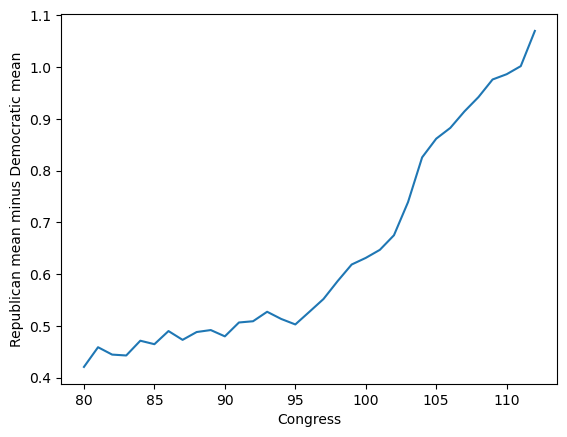

In [62]:
wide['gap'].plot(xlabel='Congress', ylabel='Republican mean minus Democratic mean');

## What we found

- The parties did **not** separate at a steady pace.
- For three decades the gap barely moved, from 0.42 in 1947 to 0.53 in 1979,
  and both parties drifted slightly left together.

- From the late 1970s the gap grew five times as fast, reaching 1.07 by 2011.
- Most of that later widening is Republicans moving right. Democrats kept
  moving left at about their earlier pace.

## Summary

| Goal | Write |
|---|---|
| Stack tables with the same columns | `pd.concat([df1, df2, ...], ignore_index=True)` |
| One summary per group | `df.groupby('g')['col'].mean()` |
| One group's rows | `df.groupby('g').get_group('a')` |
| Rows in each group | `df.groupby('g').size()` |
| Non-missing values in each group | `df.groupby('g')['col'].count()` |
| Share of rows meeting a condition, per group | `df.assign(flag=cond).groupby('g')['flag'].mean()` |
| Whole row with the largest value, per group | `df.loc[df.groupby('g')['col'].idxmax()]` |
| Several named summaries | `.agg(n=('col', 'size'), avg=('col', 'mean'))` |
| A group's summary on every row | `.transform('mean')` |
| A value per row, computed within its group | `.transform('rank')` |
| Keep or drop whole groups | `.filter(func)`, where `func` returns `True` or `False` |
| Any other operation, per group | `df.groupby('g')[cols].apply(func)` |
| A one-line function without a name | `lambda x: ...` |
| Group by two columns | `df.groupby(['a', 'b'])` |
| Index levels back to columns | `.reset_index()` |
| Long to wide, summarizing | `df.pivot_table(index=, columns=, values=, aggfunc=)` |
| Long to wide, one value per cell | `df.pivot(index=, columns=, values=)` |
| Wide to long | `df.melt(...)` |

### Three habits

1. Say which rows a mean or share is taken over **before** you compute it.
   The restriction goes before `groupby`.
2. A row of group summaries is not a row of the table. When you need a real
   member, find the row with `.idxmax()` or a sort.
3. When a `NaN` appears, ask what it means before you fill it. No rows can mean
   a count of zero, or a mean that does not exist.

### What's next

- So far we have drawn figures without explaining the plotting code. Next
  lecture covers visualization and reads that code line by line.